In [4]:
import requests
import pandas as pd
import numpy as np

# ==============================================================================
# 1. GỌI API LẤY DỮ LIỆU GỐC TỪ WHO
# ==============================================================================
url = "https://ghoapi.azureedge.net/api/LIFE_0000000030?$filter=SpatialDim eq 'VNM'"

response = requests.get(url)
if response.status_code == 200:
    raw_data = response.json()['value']
    df_who = pd.DataFrame(raw_data)
    
    # Lấy năm dữ liệu mới nhất có trong hệ thống
    latest_year = df_who['TimeDim'].max()
    
    # --------------------------------------------------------------------------
    # VẤN ĐỀ 3: METADATA DOCUMENTATION (Minh bạch nguồn dữ liệu)
    # --------------------------------------------------------------------------
    print("==================================================")
    print(f"📌 Nguồn: WHO GHO Indicator LIFE_0000000030")
    print(f"📌 Quốc gia: Vietnam (VNM)")
    print(f"📌 Năm dữ liệu: {latest_year}")
    print(f"📌 Ý nghĩa: nqx — xác suất chết trong khoảng tuổi [x, x+n)")
    print("==================================================\n")
    
    # Lọc dữ liệu theo năm mới nhất
    df_filtered = df_who[df_who['TimeDim'] == latest_year].copy()
    
    # 2. Tiền xử lý cấu trúc chuỗi
    df_filtered['Age'] = df_filtered['Dim2'].str.extract(r'AGEGROUP_YEARS(\d+)').astype(float)
    df_filtered['qx'] = df_filtered['NumericValue'].astype(float)
    df_filtered = df_filtered.dropna(subset=['Age']).sort_values('Age')
    
    # 3. Tách dữ liệu theo giới tính (Ký hiệu chuẩn của chỉ số: SEX_MLE và SEX_FMLE)
    df_male = df_filtered[df_filtered['Dim1'] == 'SEX_MLE'][['Age', 'qx']].rename(columns={'qx': 'qx_Male'})
    df_female = df_filtered[df_filtered['Dim1'] == 'SEX_FMLE'][['Age', 'qx']].rename(columns={'qx': 'qx_Female'})
    
    # Gộp chung vào một DataFrame duy nhất
    df_raw_real = pd.merge(df_male, df_female, on='Age', how='inner').reset_index(drop=True)
    
    # --------------------------------------------------------------------------
    # VẤN ĐỀ 1: SỬ DỤNG .LOC CÓ MASK RÕ RÀNG (Tránh SettingWithCopyWarning)
    # Chốt chặn nhóm tuổi cuối cùng (85+) bắt buộc phải chết hết (qx = 1.0)
    # --------------------------------------------------------------------------
    max_age_mask = df_raw_real['Age'] == df_raw_real['Age'].max()
    df_raw_real.loc[max_age_mask, ['qx_Male', 'qx_Female']] = 1.0
    
    # --------------------------------------------------------------------------
    # VẤN ĐỀ 2: KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (Data Quality Audit)
    # --------------------------------------------------------------------------
    print("--- DATA QUALITY CHECK ---")
    print(f"Null values check:\n{df_raw_real.isnull().sum()}\n")
    print(f"qx range Male: [{df_raw_real['qx_Male'].min():.4f}, {df_raw_real['qx_Male'].max():.4f}]")
    print(f"qx range Female: [{df_raw_real['qx_Female'].min():.4f}, {df_raw_real['qx_Female'].max():.4f}]")
    
    # Sanity check: Sử dụng cấu trúc kiểm định điều kiện để đảm bảo an toàn toán học
    assert (df_raw_real['qx_Male'].between(0, 1)).all(), "❌ Lỗi: qx_Male tồn tại giá trị ngoài khoảng [0,1]!"
    assert (df_raw_real['qx_Female'].between(0, 1)).all(), "❌ Lỗi: qx_Female tồn tại giá trị ngoài khoảng [0,1]!"
    print("✅ Xác thực: Tất cả giá trị qx hợp lệ nghiêm ngặt trong khoảng [0, 1]\n")
    print("--- DỮ LIỆU THÔ SẴN SÀNG ĐỂ ĐƯA VÀO CLASS LIFETABLE ---")
    print(df_raw_real)
    
else:
    print("❌ Lỗi kết nối API với WHO:", response.status_code)

📌 Nguồn: WHO GHO Indicator LIFE_0000000030
📌 Quốc gia: Vietnam (VNM)
📌 Năm dữ liệu: 2021
📌 Ý nghĩa: nqx — xác suất chết trong khoảng tuổi [x, x+n)

--- DATA QUALITY CHECK ---
Null values check:
Age          0
qx_Male      0
qx_Female    0
dtype: int64

qx range Male: [0.0014, 1.0000]
qx range Female: [0.0008, 1.0000]
✅ Xác thực: Tất cả giá trị qx hợp lệ nghiêm ngặt trong khoảng [0, 1]

--- DỮ LIỆU THÔ SẴN SÀNG ĐỂ ĐƯA VÀO CLASS LIFETABLE ---
     Age   qx_Male  qx_Female
0    0.0  0.018593   0.014180
1    1.0  0.005542   0.002928
2    5.0  0.001383   0.000840
3   10.0  0.002045   0.001131
4   15.0  0.004714   0.001606
5   20.0  0.006414   0.001903
6   25.0  0.005147   0.001682
7   30.0  0.006947   0.002599
8   35.0  0.010978   0.004358
9   40.0  0.018541   0.007289
10  45.0  0.030149   0.011812
11  50.0  0.048072   0.018949
12  55.0  0.070307   0.028122
13  60.0  0.102802   0.043532
14  65.0  0.155745   0.070856
15  70.0  0.231714   0.116673
16  75.0  0.336365   0.196508
17  80.0  0.469

In [5]:
import numpy as np
import pandas as pd

class AbridgedLifeTable:
    def __init__(self, age_array, qx_array, radix=100000, e_open_end=5.5):
        # Dữ liệu thô
        self.age = np.array(age_array, dtype=float)
        self.qx = np.array(qx_array, dtype=float)
        self.radix = radix
        
        # Các tham số giả định (Assumptions)
        self.e_open_end = e_open_end 
        
        self.n_rows = len(self.age)
        
        # Tạo mảng tính khoảng cách năm (n)
        self.n_years = np.zeros(self.n_rows)
        for i in range(self.n_rows - 1):
            self.n_years[i] = self.age[i+1] - self.age[i]
        self.n_years[-1] = 0.0 # Để 0 vì nhóm cuối là khoảng mở (open-ended)
        
        # Khởi tạo các biến số bảng sống
        self.px = np.zeros(self.n_rows)
        self.lx = np.zeros(self.n_rows)
        self.dx = np.zeros(self.n_rows)
        self.Lx = np.zeros(self.n_rows)
        self.Tx = np.zeros(self.n_rows)
        self.ex = np.zeros(self.n_rows)
        
    def calculate_table(self):
        # 1. Xác suất sống
        self.px = 1.0 - self.qx
        
        # 2. Số người sống lx và tử vong dx
        self.lx[0] = self.radix
        for i in range(self.n_rows - 1):
            self.dx[i] = self.lx[i] * self.qx[i]
            self.lx[i+1] = self.lx[i] - self.dx[i]
        
        # Nhóm cuối cùng (85+) chắc chắn tử vong toàn bộ
        self.dx[-1] = self.lx[-1]
        
        # 3. Quỹ thời gian sống nLx (Giả định UDD)
        self.Lx = self.n_years * (self.lx - 0.5 * self.dx)
        
        # Ghi đè nhóm cuối (85+) bằng tham số e_open_end linh hoạt
        self.Lx[-1] = self.lx[-1] * self.e_open_end
        
        # 4. Tổng quỹ thời gian Tx (Dồn tích ngược)
        self.Tx = np.flip(np.cumsum(np.flip(self.Lx)))
        
        # 5. Tuổi thọ kỳ vọng ex
        self.ex = self.Tx / self.lx
        
    def get_dataframe(self):
        return pd.DataFrame({
            'Age': self.age,
            'n': self.n_years,
            'qx': self.qx,
            'px': self.px,
            'lx': self.lx,
            'dx': self.dx,
            'nLx': self.Lx,
            'Tx': self.Tx,
            'ex': self.ex
        })

In [6]:
# ==============================================================================
# 3. THỰC THI MÔ HÌNH VÀ XUẤT BÁO CÁO (REPORTING)
# ==============================================================================

# 1. Chạy mô hình cho Nam giới
lt_male = AbridgedLifeTable(df_raw_real['Age'], df_raw_real['qx_Male'])
lt_male.calculate_table()
df_male_final = lt_male.get_dataframe()

# 2. Chạy mô hình cho Nữ giới
lt_female = AbridgedLifeTable(df_raw_real['Age'], df_raw_real['qx_Female'])
lt_female.calculate_table()
df_female_final = lt_female.get_dataframe()

# 3. Tổng hợp Bảng Báo Cáo Rủi Ro (Tập trung vào qx và ex)
df_summary = pd.DataFrame({
    'Age': df_male_final['Age'].astype(int),
    'qx_Male (%)': (df_male_final['qx'] * 100).round(3),
    'qx_Female (%)': (df_female_final['qx'] * 100).round(3),
    'ex_Male (Years)': df_male_final['ex'].round(2),
    'ex_Female (Years)': df_female_final['ex'].round(2)
})

# Thêm cột so sánh rủi ro (Insight cho Pricing)
df_summary['Risk_Ratio (Male/Female)'] = (df_summary['qx_Male (%)'] / df_summary['qx_Female (%)']).round(2)

print("=== BẢNG TÓM TẮT KẾT QUẢ ĐỊNH PHÍ (VIỆT NAM 2021) ===\n")
print(df_summary.head(10).to_string(index=False))

# Xuất ra file Excel để đính kèm Portfolio
df_summary.to_excel("Vietnam_LifeTable_Summary_2021.xlsx", index=False)
print("\n✅ Đã xuất báo cáo thành công ra file Excel: 'Vietnam_LifeTable_Summary_2021.xlsx'")

=== BẢNG TÓM TẮT KẾT QUẢ ĐỊNH PHÍ (VIỆT NAM 2021) ===

 Age  qx_Male (%)  qx_Female (%)  ex_Male (Years)  ex_Female (Years)  Risk_Ratio (Male/Female)
   0        1.859          1.418            69.95              78.19                      1.31
   1        0.554          0.293            70.26              78.31                      1.89
   5        0.138          0.084            66.64              74.53                      1.64
  10        0.205          0.113            61.73              69.59                      1.81
  15        0.471          0.161            56.85              64.67                      2.93
  20        0.641          0.190            52.11              59.77                      3.37
  25        0.515          0.168            47.43              54.88                      3.07
  30        0.695          0.260            42.66              49.97                      2.67
  35        1.098          0.436            37.94              45.09                      

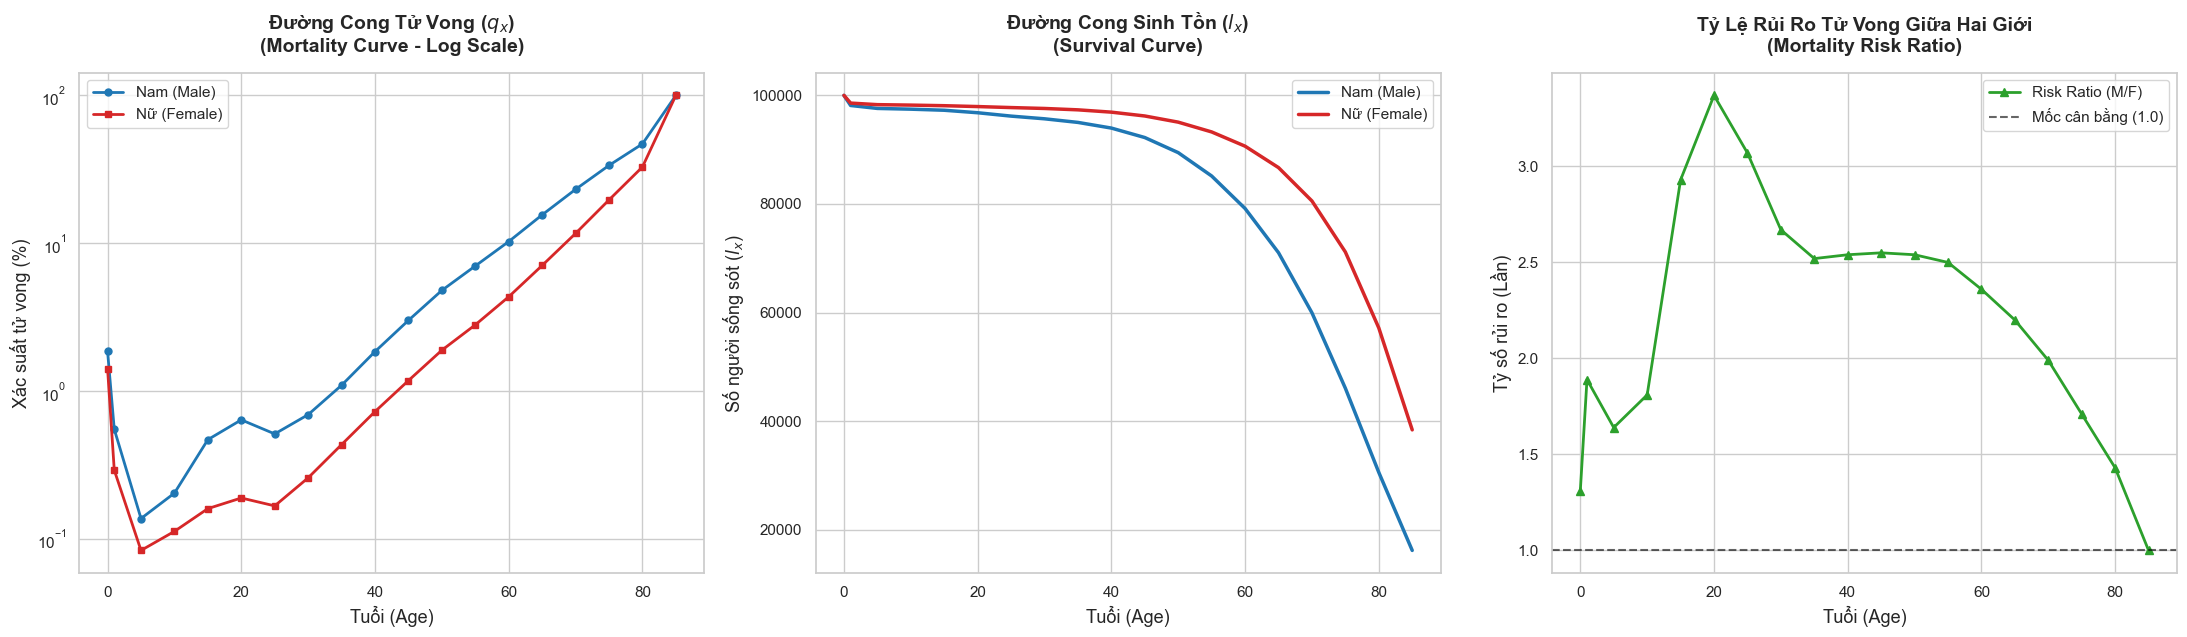

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style và cấu hình font hiển thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16
})

# Khởi tạo một khung hình gồm 3 biểu đồ hàng ngang
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

# --------------------------------------------------------------------------
# BIỂU ĐỒ 1: MORTALITY CURVE (qx) - THANG ĐO LOGARIT (LOG SCALE)
# --------------------------------------------------------------------------
axes[0].plot(df_summary['Age'], df_summary['qx_Male (%)'], 
             label='Nam (Male)', color='#1f77b4', marker='o', linewidth=2, markersize=5)
axes[0].plot(df_summary['Age'], df_summary['qx_Female (%)'], 
             label='Nữ (Female)', color='#d62728', marker='s', linewidth=2, markersize=5)

# Bắt buộc chuyển trục Y sang Log Scale để thấy rõ biến động ở độ tuổi trẻ
axes[0].set_yscale('log')  
axes[0].set_title('Đường Cong Tử Vong ($q_x$)\n(Mortality Curve - Log Scale)', pad=15, fontweight='bold')
axes[0].set_xlabel('Tuổi (Age)')
axes[0].set_ylabel('Xác suất tử vong (%)')
axes[0].legend(frameon=True)

# --------------------------------------------------------------------------
# BIỂU ĐỒ 2: SURVIVAL CURVE (lx) - THANG ĐO TUYẾN TÍNH
# --------------------------------------------------------------------------
axes[1].plot(df_male_final['Age'], df_male_final['lx'], 
             label='Nam (Male)', color='#1f77b4', linewidth=2.5)
axes[1].plot(df_female_final['Age'], df_female_final['lx'], 
             label='Nữ (Female)', color='#d62728', linewidth=2.5)

axes[1].set_title('Đường Cong Sinh Tồn ($l_x$)\n(Survival Curve)', pad=15, fontweight='bold')
axes[1].set_xlabel('Tuổi (Age)')
axes[1].set_ylabel('Số người sống sót ($l_x$)')
axes[1].legend(frameon=True)

# --------------------------------------------------------------------------
# BIỂU ĐỒ 3: MORTALITY RISK RATIO (MALE / FEMALE)
# --------------------------------------------------------------------------
axes[2].plot(df_summary['Age'], df_summary['Risk_Ratio (Male/Female)'], 
             color='#2ca02c', marker='^', linewidth=2, markersize=6, label='Risk Ratio (M/F)')
# Vẽ đường cơ sở baseline = 1.0 để làm mốc so sánh
axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Mốc cân bằng (1.0)')

axes[2].set_title('Tỷ Lệ Rủi Ro Tử Vong Giữa Hai Giới\n(Mortality Risk Ratio)', pad=15, fontweight='bold')
axes[2].set_xlabel('Tuổi (Age)')
axes[2].set_ylabel('Tỷ số rủi ro (Lần)')
axes[2].legend(frameon=True)

# Tối ưu hóa khoảng cách, tránh chồng chéo các nhãn trục
plt.tight_layout()

# Xuất file ảnh chất lượng cao (300 DPI) phục vụ chèn báo cáo PDF hoặc GitHub README
fig.savefig("vietnam_2021_actuarial_charts.png", dpi=300, bbox_inches='tight')

# Hiển thị đồ thị ngay trong notebook
plt.show()

In [ ]:
# =============================================================================
# 1. GỌI API LẤY DỮ LIỆU NĂM 2000 TỪ WHO VÀ XỬ LÝ BACK-END
# =============================================================================
url_2000 = "https://ghoapi.azureedge.net/api/LIFE_0000000030?$filter=SpatialDim eq 'VNM' and TimeDim eq 2000"
response_2000 = requests.get(url_2000)

if response_2000.status_code == 200:
    raw_data_2000 = response_2000.json()['value']
    df_who_2000 = pd.DataFrame(raw_data_2000)
    
    # Tiền xử lý cấu trúc
    df_who_2000['Age'] = df_who_2000['Dim2'].str.extract(r'AGEGROUP_YEARS(\d+)').astype(float)
    df_who_2000['qx'] = df_who_2000['NumericValue'].astype(float)
    df_who_2000 = df_who_2000.dropna(subset=['Age']).sort_values('Age')
    
    # Tách theo giới tính
    df_male_2000 = df_who_2000[df_who_2000['Dim1'] == 'SEX_MLE'][['Age', 'qx']].rename(columns={'qx': 'qx_Male'})
    df_female_2000 = df_who_2000[df_who_2000['Dim1'] == 'SEX_FMLE'][['Age', 'qx']].rename(columns={'qx': 'qx_Female'})
    df_raw_2000 = pd.merge(df_male_2000, df_female_2000, on='Age', how='inner').reset_index(drop=True)
    
    # Chốt chặn nhóm tuổi cuối cùng (85+) qx = 1.0
    df_raw_2000.loc[df_raw_2000['Age'] == df_raw_2000['Age'].max(), ['qx_Male', 'qx_Female']] = 1.0
    
    # Chạy mô hình bảng sống cho năm 2000
    lt_male_2000 = AbridgedLifeTable(df_raw_2000['Age'], df_raw_2000['qx_Male'])
    lt_male_2000.calculate_table()
    df_male_2000_final = lt_male_2000.get_dataframe()
    
    lt_female_2000 = AbridgedLifeTable(df_raw_2000['Age'], df_raw_2000['qx_Female'])
    lt_female_2000.calculate_table()
    df_female_2000_final = lt_female_2000.get_dataframe()
    
    print("✅ Đã tải và tính toán xong dữ liệu Bảng sống Việt Nam năm 2000!")
else:
    print("❌ Lỗi kết nối API:", response_2000.status_code)

# =============================================================================
# 2. TRỰC QUAN HÓA SO SÁNH THỜI GIAN (VN 2000 VS VN 2021)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --- BIỂU ĐỒ 1: SỰ CẢI THIỆN ĐƯỜNG CONG TỬ VONG (qx) ---
# Nam giới (2000 vs 2021)
axes[0].plot(df_male_2000_final['Age'], df_male_2000_final['qx'] * 100, 
             label='Nam 2000', color='#1f77b4', linestyle='--', marker='o', alpha=0.6)
axes[0].plot(df_male_final['Age'], df_male_final['qx'] * 100, 
             label='Nam 2021', color='#1f77b4', linestyle='-', marker='o', linewidth=2.5)

# Nữ giới (2000 vs 2021)
axes[0].plot(df_female_2000_final['Age'], df_female_2000_final['qx'] * 100, 
             label='Nữ 2000', color='#d62728', linestyle='--', marker='s', alpha=0.6)
axes[0].plot(df_female_final['Age'], df_female_final['qx'] * 100, 
             label='Nữ 2021', color='#d62728', linestyle='-', marker='s', linewidth=2.5)

axes[0].set_yscale('log')
axes[0].set_title('So Sánh Đường Cong Tử Vong ($q_x$)\n2000 vs 2021 (Log Scale)', pad=15, fontweight='bold')
axes[0].set_xlabel('Tuổi (Age)')
axes[0].set_ylabel('Xác suất tử vong (%)')
axes[0].legend(frameon=True)

# --- BIỂU ĐỒ 2: SỰ DỊCH CHUYỂN ĐƯỜNG CONG SINH TỒN (lx) ---
# Nam giới (2000 vs 2021)
axes[1].plot(df_male_2000_final['Age'], df_male_2000_final['lx'], 
             label='Nam 2000', color='#1f77b4', linestyle='--', alpha=0.6)
axes[1].plot(df_male_final['Age'], df_male_final['lx'], 
             label='Nam 2021', color='#1f77b4', linestyle='-', linewidth=2.5)

# Nữ giới (2000 vs 2021)
axes[1].plot(df_female_2000_final['Age'], df_female_2000_final['lx'], 
             label='Nữ 2000', color='#d62728', linestyle='--', alpha=0.6)
axes[1].plot(df_female_final['Age'], df_female_final['lx'], 
             label='Nữ 2021', color='#d62728', linestyle='-', linewidth=2.5)

axes[1].set_title('Sự Dịch Chuyển Đường Cong Sinh Tồn ($l_x$)\n2000 vs 2021', pad=15, fontweight='bold')
axes[1].set_xlabel('Tuổi (Age)')
axes[1].set_ylabel('Số người sống sót ($l_x$)')
axes[1].legend(frameon=True)

plt.tight_layout()
fig.savefig("vietnam_temporal_comparison_2000_2021.png", dpi=300, bbox_inches='tight')
plt.show()